# 01 - Data Exploration

Load stock prices, inspect returns distribution, and visualize the correlation structure of our 15-stock universe.

In [1]:
import sys, os
sys.path.insert(0, '../src')
import yaml
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from data_loader import compute_monthly_returns, compute_stats

## Load config and prices

> **Note:** `data_loader.fetch_prices()` pulls live data via `yfinance`. If you're re-running this without internet access to Yahoo Finance, run `src/synthetic_data.py` first to regenerate `data/stock_prices.csv`.

In [2]:
with open('../configs/tickers.yaml') as f:
    tickers = yaml.safe_load(f)['tickers']
with open('../configs/params.yaml') as f:
    params = yaml.safe_load(f)

prices = pd.read_csv('../data/stock_prices.csv', index_col=0, parse_dates=True)
prices.head()

,AAPL,AMZN,CAT,DIS,GOOGL,HD,JNJ,JPM,KO,META,MSFT,PG,SPY,UNH,V,XOM
Date,,,,,,,,,,,,,,,,
2021-01-04,125.740868,159.331497,164.929306,172.272003,85.547935,230.376846,134.287384,109.000534,44.792778,266.598816,207.956131,119.853638,342.436981,317.846802,209.139374,33.466637
2021-01-05,127.295464,160.925507,166.278519,173.008865,86.237816,232.236084,135.866196,109.593620,44.300362,268.611115,208.156754,120.618896,344.795380,313.572418,206.018021,35.079483
2021-01-06,123.010521,156.919006,175.532288,173.668152,85.386864,233.562973,137.144714,114.739677,42.891037,261.017883,202.759369,121.888588,346.856842,326.731873,204.202850,35.974617
2021-01-07,127.208046,158.108002,175.867279,173.144592,87.937233,232.419479,137.608063,118.507645,42.415604,266.400635,208.529282,120.749352,352.010193,331.970245,205.345688,36.256863
2021-01-08,128.306030,159.134995,175.894470,173.251236,89.101425,234.889771,137.324860,118.638466,43.366470,265.240784,209.799835,120.697166,354.015808,330.478760,206.920837,36.660076


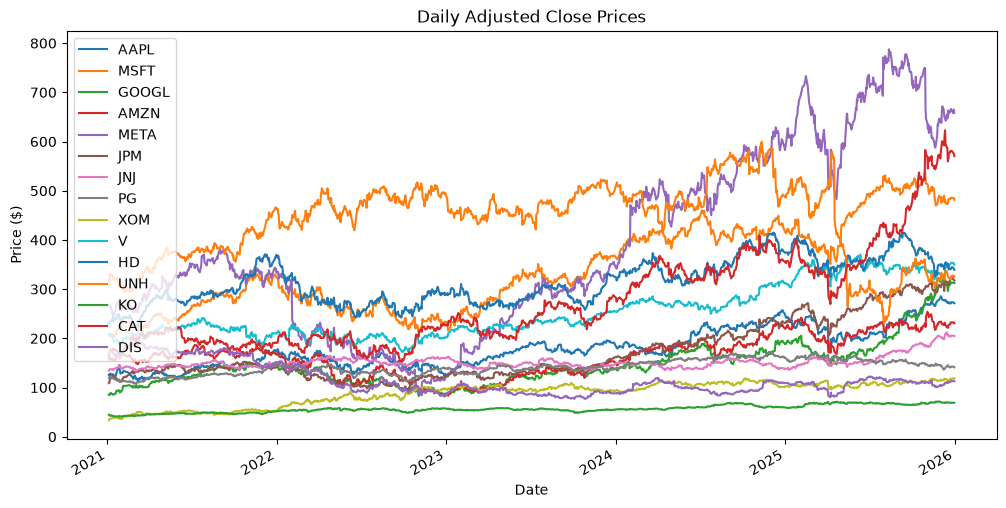

In [3]:
prices[tickers].plot(figsize=(12, 6), legend=True, title='Daily Adjusted Close Prices')
plt.ylabel('Price ($)')
plt.show()

## Monthly returns and covariance

In [4]:
monthly_returns = compute_monthly_returns(prices[tickers])
mean_returns, cov_matrix = compute_stats(monthly_returns)

print('Annualized mean returns:')
mean_returns.sort_values(ascending=False)

Annualized mean returns:


CAT      0.309126
GOOGL    0.294055
META     0.280973
XOM      0.278032
JPM      0.241721
MSFT     0.183070
AAPL     0.183012
V        0.147978
AMZN     0.121790
KO       0.119209
HD       0.102172
JNJ      0.090525
UNH      0.062168
PG       0.061441
DIS     -0.021644
dtype: float64

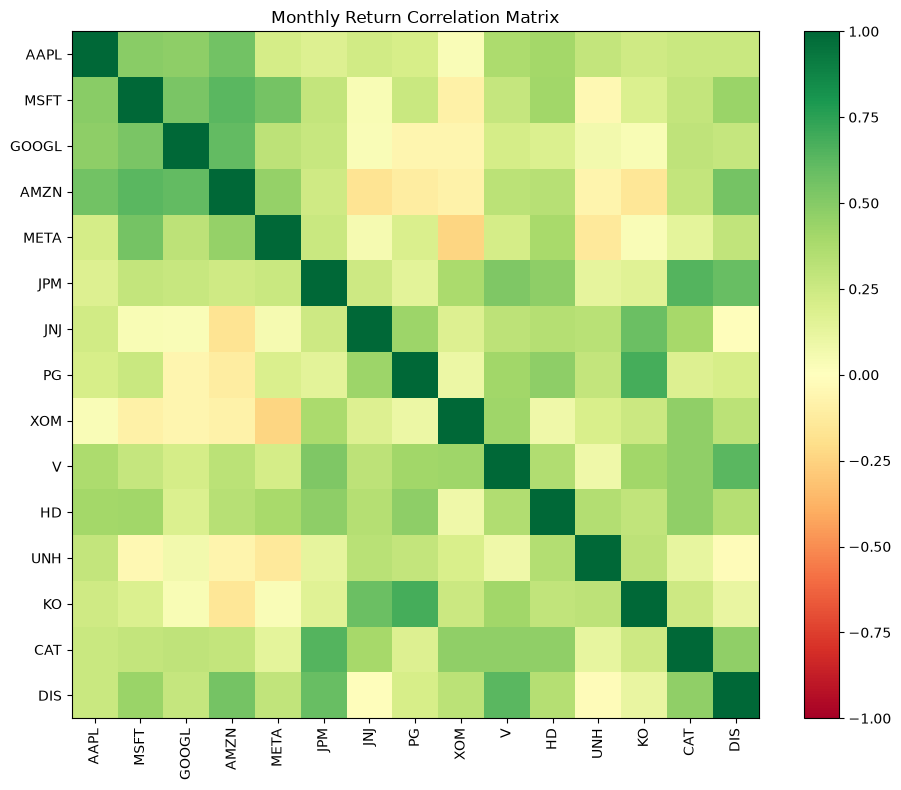

In [5]:
fig, ax = plt.subplots(figsize=(10, 8))
corr = monthly_returns.corr()
im = ax.imshow(corr, cmap='RdYlGn', vmin=-1, vmax=1)
ax.set_xticks(range(len(tickers))); ax.set_xticklabels(tickers, rotation=90)
ax.set_yticks(range(len(tickers))); ax.set_yticklabels(tickers)
plt.colorbar(im)
ax.set_title('Monthly Return Correlation Matrix')
plt.tight_layout()
plt.show()

## Risk-return snapshot per stock

In [6]:
vol = monthly_returns.std() * np.sqrt(12)
summary = pd.DataFrame({'Annual Return': mean_returns, 'Annual Volatility': vol})
summary['Return/Vol'] = summary['Annual Return'] / summary['Annual Volatility']
summary.sort_values('Return/Vol', ascending=False)

,Annual Return,Annual Volatility,Return/Vol
GOOGL,0.294055,0.282630,1.040425
XOM,0.278032,0.269441,1.031882
JPM,0.241721,0.241545,1.000727
CAT,0.309126,0.344997,0.896025
MSFT,0.183070,0.224792,0.814396
V,0.147978,0.197046,0.750982
KO,0.119209,0.159134,0.749110
AAPL,0.183012,0.247022,0.740875
META,0.280973,0.412693,0.680827
JNJ,0.090525,0.163358,0.554154
